In [29]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    from helper_functions import PROCESSED_DIR
except ImportError:
    PROJECT_ROOT = Path.cwd()

    PROJECT_ROOT = PROJECT_ROOT.parent.parent.parent

    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

RQ2_METADATA_DIR = PROCESSED_DIR / "RQ2_metadata_interpretable_features"
PLOTS_DIR = PROJECT_ROOT / "plots" / "RQ2_metadata_interpretable_features"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

metadata_coverage = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_feature_coverage.parquet"
)

genre_window_summary = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_genre_window_summary.parquet"
)

eligible_genre_window_summary = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_eligible_genre_window_summary.parquet"
)

all_genres_window_summary = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_all_genres_window_summary.parquet"
)

genre_window_z_summary = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_genre_window_within_period_z_summary.parquet"
)

eligible_genre_window_z_summary = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_eligible_genre_window_within_period_z_summary.parquet"
)

feature_deviation_summary = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_feature_deviation_summary.parquet"
)

mode_window_summary = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_mode_window_summary.parquet"
)

all_genres_mode_summary = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_all_genres_mode_summary.parquet"
)

key_window_counts = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_key_window_counts.parquet"
)

early_late_summary = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_early_late_summary.parquet"
)

early_late_changes = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_early_late_feature_changes.parquet"
)

all_genres_feature_change = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_all_genres_first_last_change.parquet"
)

genre_feature_trends = pd.read_parquet(
    RQ2_METADATA_DIR / "metadata_genre_feature_trends.parquet"
)

continuous_features = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "duration_ms",
]

metadata_features = [
    "danceability",
    "energy",
    "key",
    "mode",
    "valence",
    "tempo",
    "duration_ms",
]

print("Loaded RQ2 metadata results")
print("metadata_coverage:", metadata_coverage.shape)
print("eligible_genre_window_summary:", eligible_genre_window_summary.shape)
print("all_genres_window_summary:", all_genres_window_summary.shape)
print("feature_deviation_summary:", feature_deviation_summary.shape)
print("genre_feature_trends:", genre_feature_trends.shape)

Loaded RQ2 metadata results
metadata_coverage: (7, 5)
eligible_genre_window_summary: (2198, 13)
all_genres_window_summary: (61, 12)
feature_deviation_summary: (250, 6)
genre_feature_trends: (250, 10)


### coverage

In [30]:
metadata_coverage

,feature,n_tracks,n_non_missing,n_missing,missing_share
0,danceability,97883,97883,0,0.0
1,energy,97883,97883,0,0.0
2,key,97883,97883,0,0.0
3,mode,97883,97883,0,0.0
4,valence,97883,97883,0,0.0
5,tempo,97883,97883,0,0.0
6,duration_ms,97883,97883,0,0.0


### Main All-Genres Trajectories

In [31]:
all_genres_window_summary

,window_start,window_end,window_label,n_tracks,n_genres,danceability,energy,key,mode,valence,tempo,duration_ms
0,1955,1959,1955_1959,327,11,0.507339,0.306113,5.045872,0.703364,0.484011,113.622685,223688.137615
1,1956,1960,1956_1960,360,12,0.521556,0.326683,5.061111,0.675000,0.515073,114.081281,222793.375000
2,1957,1961,1957_1961,336,14,0.521504,0.334551,5.083333,0.684524,0.515424,114.812256,232839.669643
3,1958,1962,1958_1962,341,15,0.520570,0.353281,5.351906,0.712610,0.532370,115.748935,224673.862170
4,1959,1963,1959_1963,375,15,0.514289,0.375184,5.258667,0.706667,0.571000,116.186312,215738.160000
...,...,...,...,...,...,...,...,...,...,...,...,...
56,2011,2015,2011_2015,21906,50,0.514639,0.678632,5.322195,0.606409,0.411355,123.439867,243786.961426
57,2012,2016,2012_2016,23773,50,0.520936,0.675009,5.325495,0.600892,0.409157,122.846470,241883.163463
58,2013,2017,2013_2017,26974,50,0.528775,0.666556,5.307555,0.596649,0.407808,122.399499,239544.502780
59,2014,2018,2014_2018,31503,50,0.539354,0.664128,5.283656,0.595308,0.411328,122.342930,235514.377107


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_metadata_interpretable_features/metadata_all_genres_feature_trajectories_combined.png


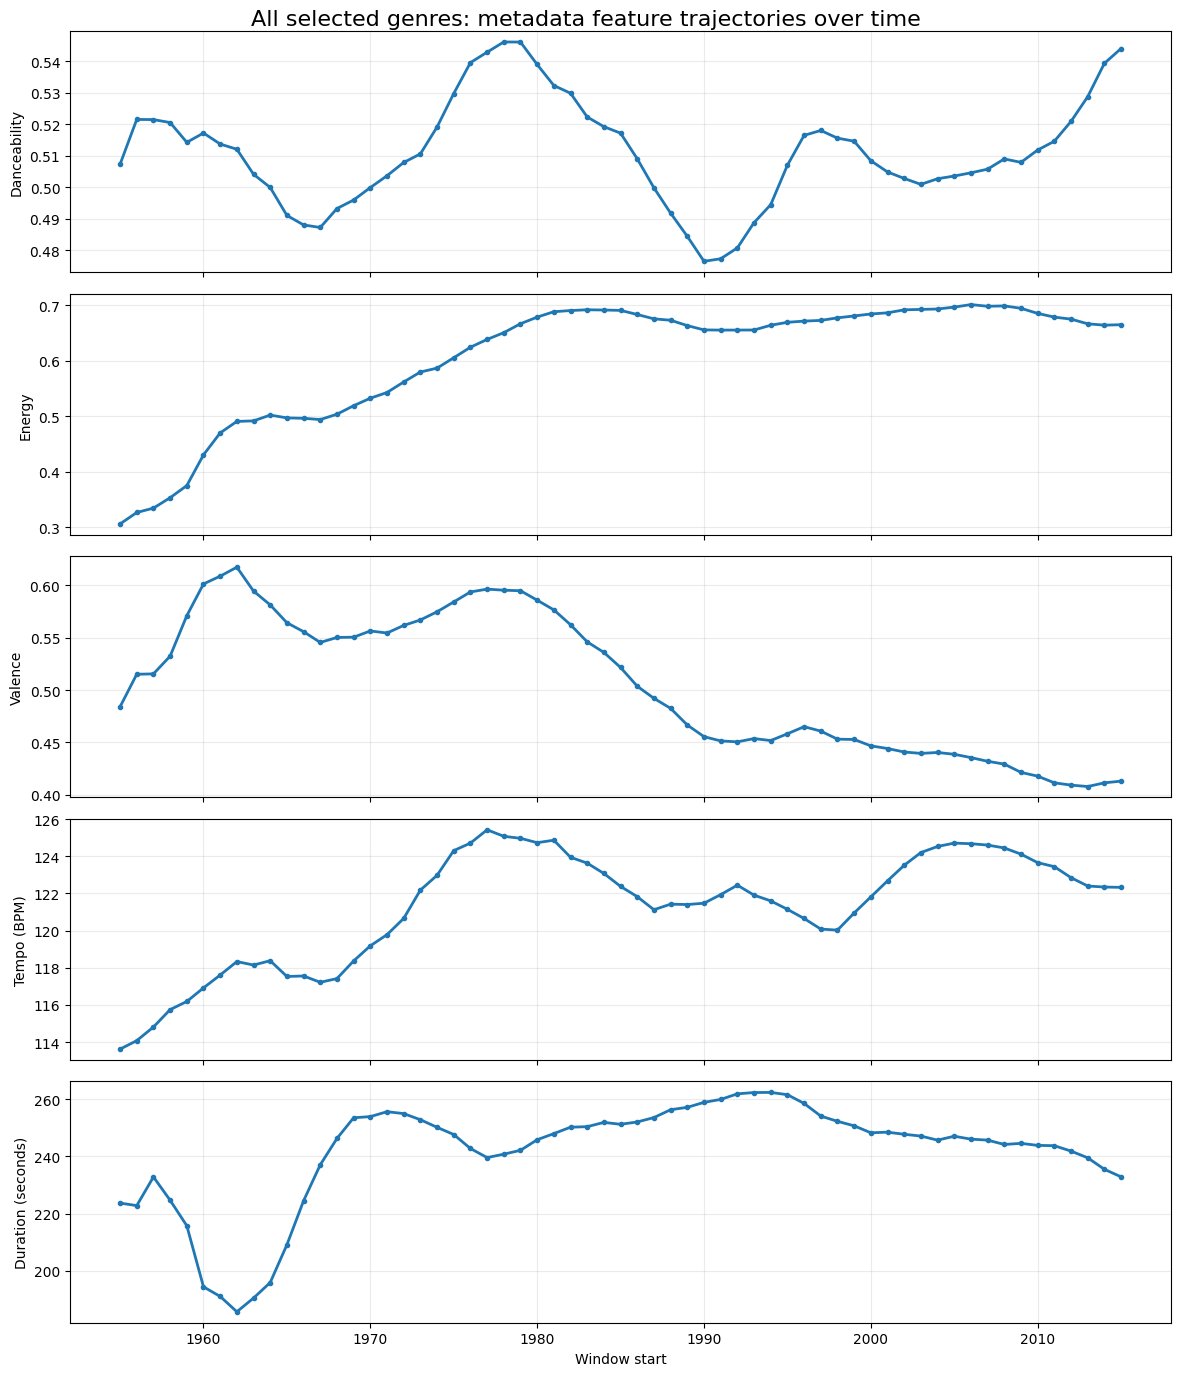

In [32]:
plot_data = all_genres_window_summary.sort_values("window_start").copy()
plot_data["duration_seconds"] = plot_data["duration_ms"] / 1000

features_to_plot = [
    ("danceability", "Danceability"),
    ("energy", "Energy"),
    ("valence", "Valence"),
    ("tempo", "Tempo (BPM)"),
    ("duration_seconds", "Duration (seconds)"),
]

fig, axes = plt.subplots(
    nrows=len(features_to_plot),
    ncols=1,
    figsize=(12, 14),
    sharex=True,
)

for ax, (feature, label) in zip(axes, features_to_plot):
    ax.plot(
        plot_data["window_start"],
        plot_data[feature],
        marker="o",
        markersize=3,
        linewidth=2,
    )

    ax.set_ylabel(label)
    ax.grid(alpha=0.25)

axes[-1].set_xlabel("Window start")

fig.suptitle(
    "All selected genres: metadata feature trajectories over time",
    fontsize=16,
)

plt.tight_layout()

output_path = PLOTS_DIR / "metadata_all_genres_feature_trajectories_combined.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

In [33]:
all_genres_feature_change

,feature,first_window_value,last_window_value,last_minus_first
0,danceability,0.507339,0.544058,0.036718
1,energy,0.306113,0.664949,0.358836
2,valence,0.484011,0.412968,-0.071043
3,tempo,113.622685,122.325210,8.702525
4,duration_ms,223688.137615,232870.714414,9182.576799


### Genre-Level Raw Trajectories

In [34]:
eligible_genre_window_summary

,genre,window_start,window_end,window_label,n_tracks,danceability,energy,key,mode,valence,tempo,duration_ms,eligible_window
0,alternative rock,1979,1983,1979_1983,30,0.471000,0.674407,4.533333,0.733333,0.657350,136.802233,227990.266667,True
1,alternative rock,1980,1984,1980_1984,44,0.473477,0.668517,5.181818,0.704545,0.659057,135.427841,217900.613636,True
2,alternative rock,1981,1985,1981_1985,55,0.463236,0.677414,5.327273,0.709091,0.626636,135.779145,207164.909091,True
3,alternative rock,1982,1986,1982_1986,60,0.456950,0.684513,5.516667,0.733333,0.626517,136.239150,209528.050000,True
4,alternative rock,1983,1987,1983_1987,79,0.481063,0.686896,5.493671,0.683544,0.608866,131.433532,208251.113924,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193,thrash metal,2011,2015,2011_2015,106,0.384793,0.936453,5.141509,0.547170,0.320900,129.811160,261777.849057,True
2194,thrash metal,2012,2016,2012_2016,118,0.367645,0.950483,5.008475,0.550847,0.292713,128.513703,282077.720339,True
2195,thrash metal,2013,2017,2013_2017,158,0.359672,0.941456,5.398734,0.556962,0.289992,125.335013,272035.759494,True
2196,thrash metal,2014,2018,2014_2018,200,0.356031,0.942330,5.510000,0.590000,0.270960,125.283600,278736.210000,True


In [35]:
genre_feature_trends

,feature,genre,n_valid_windows,first_window,last_window,first_value,last_value,last_minus_first,mean_value,median_value
0,danceability,alternative rock,37,1979,2015,0.471000,0.482567,0.011567,0.473243,0.472820
1,danceability,ambient,43,1971,2015,0.338750,0.437306,0.098556,0.388129,0.377611
2,danceability,black metal,36,1980,2015,0.235800,0.288976,0.053176,0.261501,0.268961
3,danceability,blues,61,1955,2015,0.522256,0.537601,0.015346,0.535423,0.537601
4,danceability,bossa nova,54,1960,2015,0.536950,0.585275,0.048325,0.564900,0.571544
...,...,...,...,...,...,...,...,...,...,...
245,duration_ms,soft rock,49,1967,2015,197901.428571,235268.843750,37367.415179,247922.604456,249083.718750
246,duration_ms,soul,61,1955,2015,188492.450000,223082.032710,34589.582710,237930.562917,242201.601307
247,duration_ms,soundtrack,44,1965,2015,161628.904762,193769.077083,32140.172321,217295.316613,210326.502517
248,duration_ms,synthpop,41,1975,2015,283131.250000,235358.088701,-47773.161299,264625.117145,266183.165049


In [37]:
from sklearn.linear_model import LinearRegression

def calculate_linear_slope(data, feature):
    data = data.sort_values("window_start").dropna(subset=[feature])

    if len(data) < 2:
        return np.nan

    x = data["window_start"].to_numpy().reshape(-1, 1)
    y = data[feature].to_numpy()

    model = LinearRegression()
    model.fit(x, y)

    return model.coef_[0]


slope_rows = []

for feature in continuous_features:
    for genre, genre_data in eligible_genre_window_summary.groupby("genre"):
        slope = calculate_linear_slope(genre_data, feature)

        slope_rows.append({
            "feature": feature,
            "genre": genre,
            "slope_per_year": slope,
            "n_valid_windows": genre_data["window_start"].nunique(),
        })

genre_feature_slopes = pd.DataFrame(slope_rows)

all_genres_slope_rows = []

for feature in continuous_features:
    slope = calculate_linear_slope(all_genres_window_summary, feature)

    all_genres_slope_rows.append({
        "feature": feature,
        "genre": "All selected genres",
        "slope_per_year": slope,
        "n_valid_windows": all_genres_window_summary["window_start"].nunique(),
    })

all_genres_feature_slopes = pd.DataFrame(all_genres_slope_rows)

genre_feature_slopes.to_csv(
    PLOTS_DIR / "metadata_genre_feature_linear_slopes.csv",
    index=False,
)

all_genres_feature_slopes.to_csv(
    PLOTS_DIR / "metadata_all_genres_feature_linear_slopes.csv",
    index=False,
)

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_metadata_interpretable_features/metadata_genre_feature_linear_trend_top5_inc_dec_danceability.png


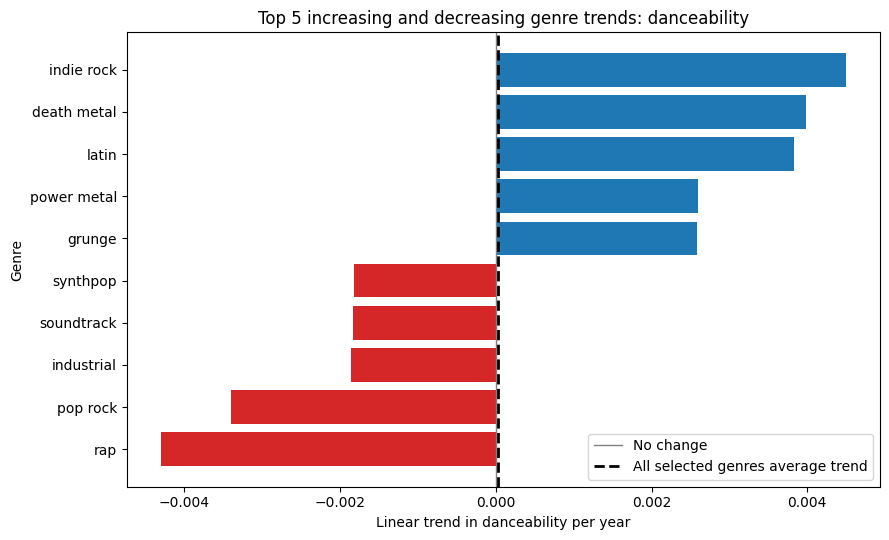

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_metadata_interpretable_features/metadata_genre_feature_linear_trend_top5_inc_dec_energy.png


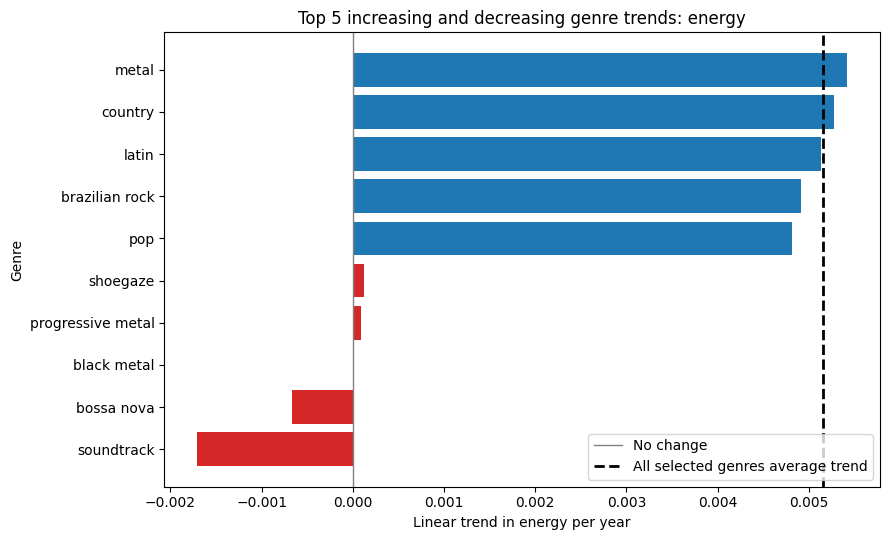

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_metadata_interpretable_features/metadata_genre_feature_linear_trend_top5_inc_dec_valence.png


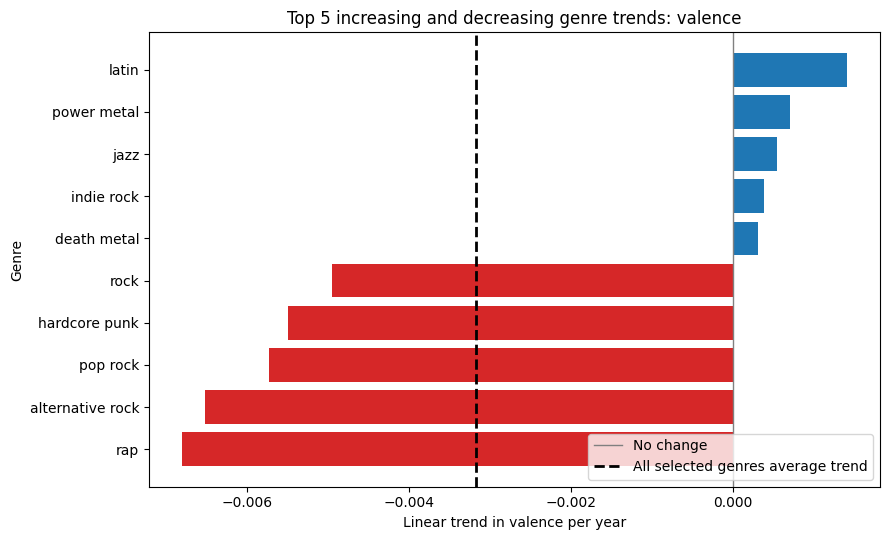

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_metadata_interpretable_features/metadata_genre_feature_linear_trend_top5_inc_dec_tempo.png


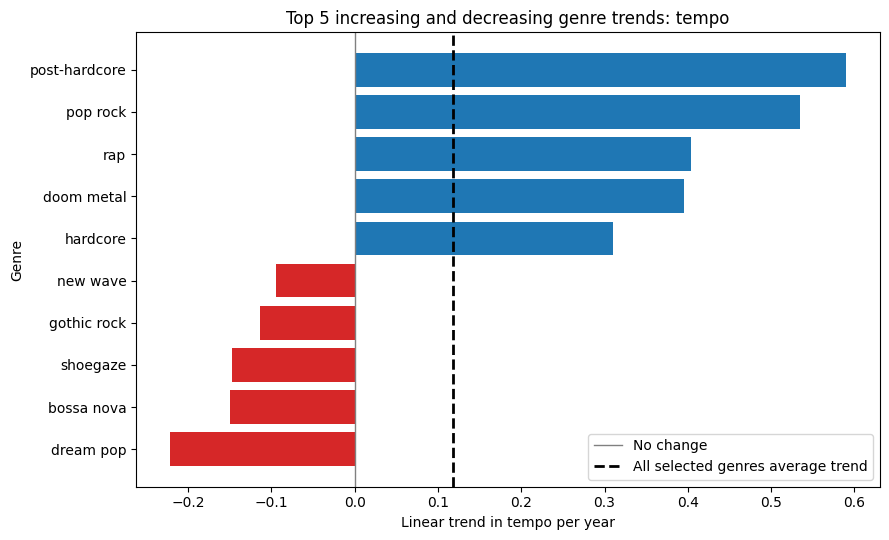

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_metadata_interpretable_features/metadata_genre_feature_linear_trend_top5_inc_dec_duration_ms.png


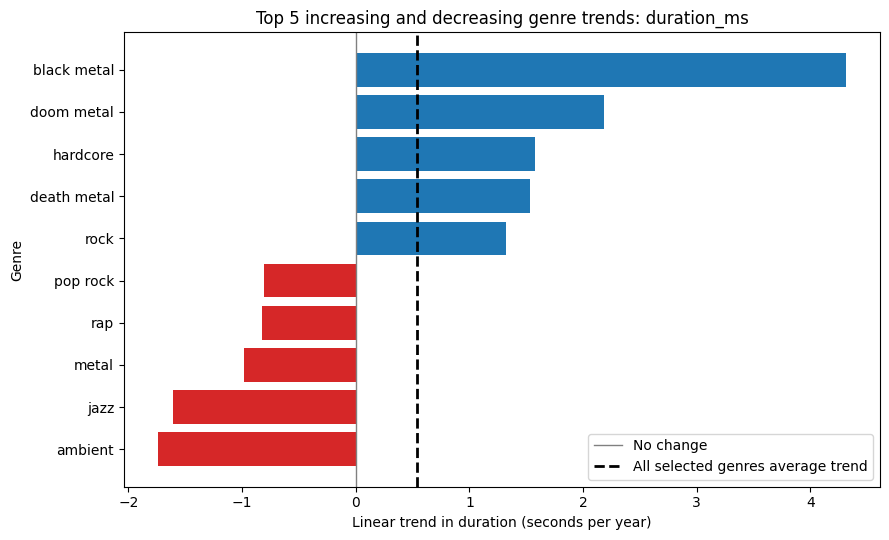

In [41]:
for feature in continuous_features:
    plot_data = (
        genre_feature_slopes[
            genre_feature_slopes["feature"] == feature
        ]
        .dropna(subset=["slope_per_year"])
        .copy()
    )

    reference_slope = all_genres_feature_slopes.loc[
        all_genres_feature_slopes["feature"] == feature,
        "slope_per_year",
    ].iloc[0]

    if feature == "duration_ms":
        plot_data["slope_for_plot"] = plot_data["slope_per_year"] / 1000
        reference_for_plot = reference_slope / 1000
        x_label = "Linear trend in duration (seconds per year)"
    else:
        plot_data["slope_for_plot"] = plot_data["slope_per_year"]
        reference_for_plot = reference_slope
        x_label = f"Linear trend in {feature} per year"

    strongest_decrease = plot_data.nsmallest(5, "slope_for_plot").assign(
        trend_group="Top 5 decreasing"
    )

    strongest_increase = plot_data.nlargest(5, "slope_for_plot").assign(
        trend_group="Top 5 increasing"
    )

    plot_data = pd.concat(
        [strongest_decrease, strongest_increase],
        ignore_index=True,
    ).sort_values("slope_for_plot")

    colors = plot_data["trend_group"].map({
        "Top 5 decreasing": "tab:red",
        "Top 5 increasing": "tab:blue",
    })

    plt.figure(figsize=(9, 5.5))
    plt.barh(
        plot_data["genre"],
        plot_data["slope_for_plot"],
        color=colors,
    )

    plt.axvline(
        0,
        color="grey",
        linewidth=1,
        linestyle="-",
        label="No change",
    )

    plt.axvline(
        reference_for_plot,
        color="black",
        linewidth=2,
        linestyle="--",
        label="All selected genres average trend",
    )

    plt.xlabel(x_label)
    plt.ylabel("Genre")
    plt.title(f"Top 5 increasing and decreasing genre trends: {feature}")

    plt.legend(loc="lower right")
    plt.tight_layout()

    safe_feature = feature.replace("/", "_").replace(" ", "_")
    output_path = (
        PLOTS_DIR
        / f"metadata_genre_feature_linear_trend_top5_inc_dec_{safe_feature}.png"
    )

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(output_path)

    plt.show()

### Within-Period Normalized Genre Positions

In [10]:
eligible_genre_window_z_summary

,genre,window_start,window_end,window_label,n_tracks,danceability,energy,key,mode,valence,tempo,duration_ms,eligible_window
0,blues,1955,1959,1955_1959,43,0.097252,-0.008812,-0.140934,0.191197,-0.025192,-0.183547,-0.264026,True
1,classic rock,1955,1959,1955_1959,26,0.615164,1.515351,-0.179962,0.481010,1.500879,0.339573,-0.690338,True
2,country,1955,1959,1955_1959,23,1.105307,0.465483,-0.251960,0.554229,0.781063,0.159545,-0.542785,True
3,jazz,1955,1959,1955_1959,179,-0.338039,-0.444682,0.102974,-0.292336,-0.411703,-0.059252,0.386883,True
4,rock,1955,1959,1955_1959,22,0.728007,1.002217,-0.420424,0.450391,0.919753,0.171282,-0.715432,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193,soft rock,2015,2019,2015_2019,64,0.292379,-0.273694,0.105213,0.315050,0.509532,-0.101653,0.027295,True
2194,soul,2015,2019,2015_2019,1070,0.272439,-0.527924,0.062857,-0.182876,0.068564,-0.214712,-0.111414,True
2195,soundtrack,2015,2019,2015_2019,480,-0.643288,-1.055015,-0.043021,-0.037251,-0.517671,-0.330238,-0.445052,True
2196,synthpop,2015,2019,2015_2019,947,0.327484,0.072538,-0.049997,-0.046928,0.124353,-0.076020,0.028311,True


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_metadata_interpretable_features/metadata_relative_position_heatmap_valence.png


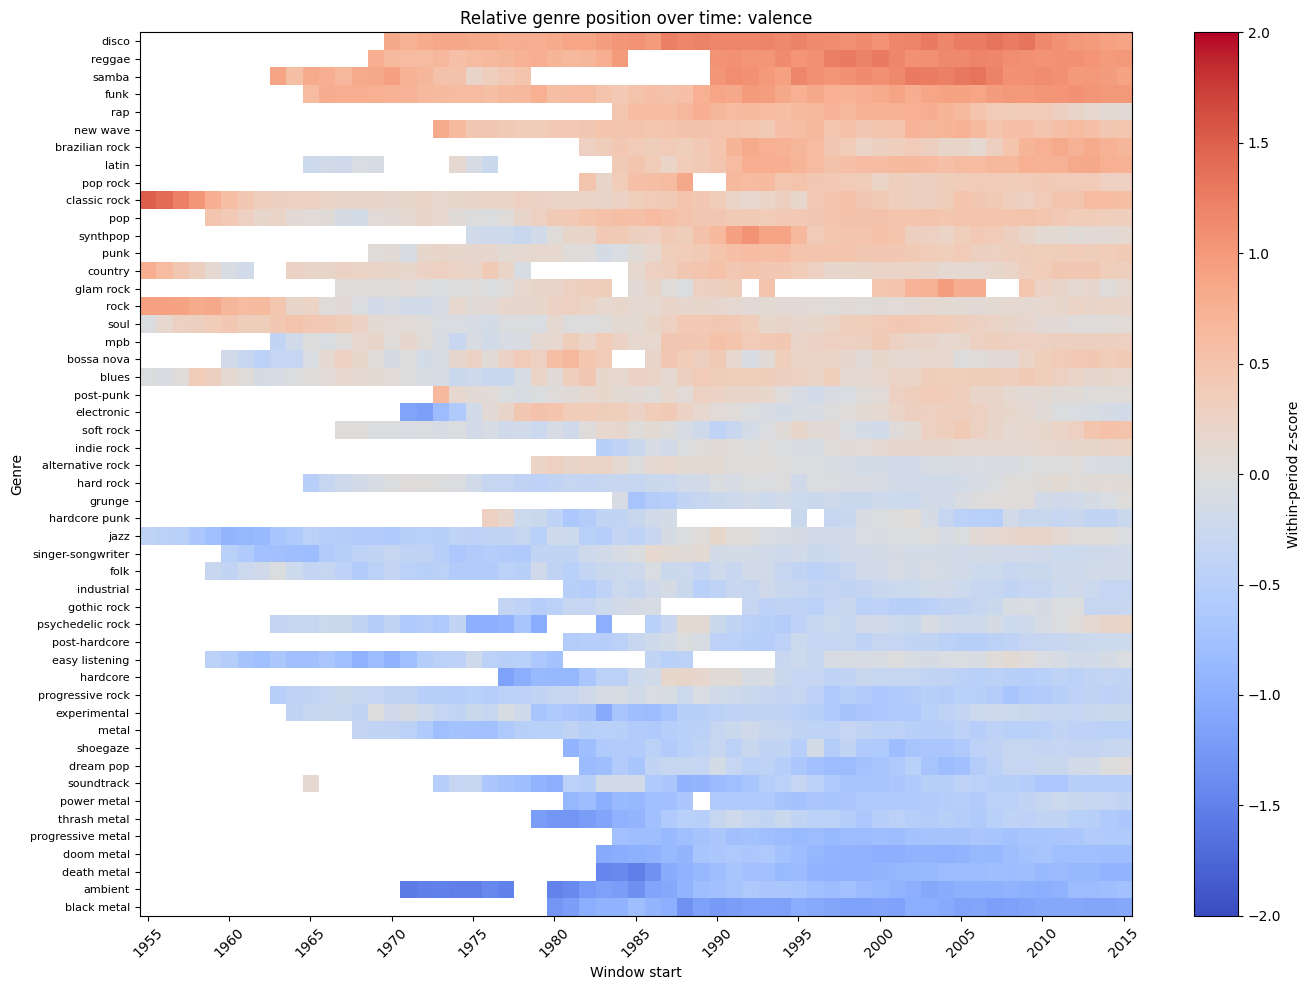

In [25]:
selected_feature = "valence"  # change to danceability, energy, tempo, duration_ms

heatmap_data = eligible_genre_window_z_summary.pivot_table(
    index="genre",
    columns="window_start",
    values=selected_feature,
    aggfunc="mean",
)

genre_order = (
    heatmap_data
    .mean(axis=1)
    .sort_values(ascending=False)
    .index
)

heatmap_data = heatmap_data.loc[genre_order]

plt.figure(figsize=(14, 10))
plt.imshow(
    heatmap_data.to_numpy(),
    aspect="auto",
    cmap="coolwarm",
    vmin=-2,
    vmax=2,
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index,
    fontsize=8,
)

plt.xticks(
    range(0, len(heatmap_data.columns), 5),
    heatmap_data.columns[::5],
    rotation=45,
)

plt.xlabel("Window start")
plt.ylabel("Genre")
plt.title(f"Relative genre position over time: {selected_feature}")
plt.colorbar(label="Within-period z-score")
plt.tight_layout()

output_path = PLOTS_DIR / f"metadata_relative_position_heatmap_{selected_feature}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

In [11]:
feature_deviation_summary

,genre,n_valid_windows,mean_relative_position,median_relative_position,mean_absolute_relative_position,feature
0,alternative rock,37,-0.212336,-0.198314,0.212336,danceability
1,ambient,43,-0.716272,-0.776005,0.719793,danceability
2,black metal,36,-1.411970,-1.408437,1.411970,danceability
3,blues,61,0.142225,0.138555,0.158329,danceability
4,bossa nova,54,0.313077,0.280467,0.323162,danceability
...,...,...,...,...,...,...
245,soft rock,49,0.003437,-0.017318,0.114405,duration_ms
246,soul,61,-0.016632,-0.054756,0.187430,duration_ms
247,soundtrack,44,-0.317957,-0.368399,0.323896,duration_ms
248,synthpop,41,0.167086,0.179304,0.188174,duration_ms


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ2_metadata_interpretable_features/metadata_top_deviating_genres_valence.png


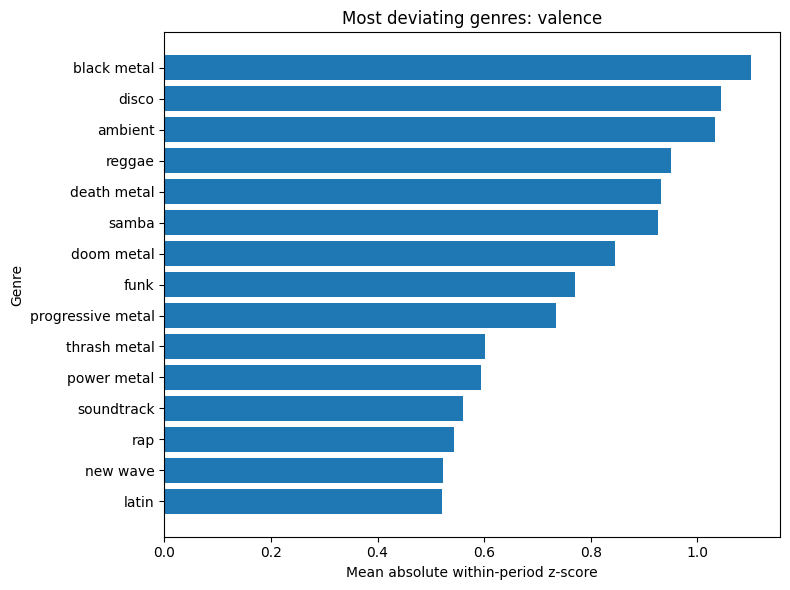

In [26]:
selected_feature = "valence"  # change to danceability, energy, tempo, duration_ms
top_n = 15

plot_data = (
    feature_deviation_summary[
        feature_deviation_summary["feature"] == selected_feature
    ]
    .sort_values("mean_absolute_relative_position", ascending=True)
    .tail(top_n)
)

plt.figure(figsize=(8, 6))
plt.barh(
    plot_data["genre"],
    plot_data["mean_absolute_relative_position"],
)

plt.xlabel("Mean absolute within-period z-score")
plt.ylabel("Genre")
plt.title(f"Most deviating genres: {selected_feature}")
plt.tight_layout()

output_path = PLOTS_DIR / f"metadata_top_deviating_genres_{selected_feature}.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()